# IND320 Course Project, Part 3


## Code access and direct links

- The project is deployed here: [ind320-henrikengdal-project](https://ind320-henrikengdal-project.streamlit.app/)
- The code is accessible at the repository: [henrikengdal/ind320-henrikengdal-project](https://github.com/HenrikEngd/IND320-HenrikEngdal-Project.git)

## AI Usage

AI plays a multifaceted role throughout this project, primarily serving as an assistant and analytical tool. The project leverages AI in several areas:

**Development and Code Generation:**
AI assists in writing and optimizing code for the application. 

**Data Analysis and Insights:**
AI helps analyze data patterns and identifying trends. It assists in generating meaningful statistical summaries and suggesting appropriate visualization techniques for the given data.

**Documentation and Communication:**
AI supports the creation of clear documentation, such as code comments, and user interface text. It helps structure the project documentation and ensures technical concepts are communicated effectively.

**Problem-Solving and Debugging:**
Throughout the development process, AI serves as a coding companion, helping troubleshoot issues, optimize data processing workflows, and suggesting best practices.

## Defining representatives


In [6]:
import pandas as pd
price_areas = {
    'NO1': ('Oslo', 10.7522, 59.9139),
    'NO2': ('Kristiansand', 7.9956, 58.1467),
    'NO3': ('Trondheim', 10.3951, 63.4305),
    'NO4': ('Tromsø', 18.9553, 69.6496),
    'NO5': ('Bergen', 5.3221, 60.3913)
}
df = pd.DataFrame.from_dict(price_areas, orient='index', columns=['City', 'Longitude', 'Latitude'])


## API Download

In [7]:
import requests_cache
from datetime import datetime

# Fallback if retry_requests is not available
try:
    from retry_requests import retry
except Exception:
    def retry(session, retries: int = 0, backoff_factor: float = 0.0):
        return session

# Use ERA5 archive endpoint for historical data like 2019
BASE_URL = "https://archive-api.open-meteo.com/v1/era5"
HOUR_VARS = [
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "windgusts_10m",
    "winddirection_10m",
]

# Cached session with retries for resilient API calls
_session = requests_cache.CachedSession(
    cache_name="openmeteo_cache", backend="sqlite", expire_after=60 * 60 * 24
)
_session = retry(_session, retries=3, backoff_factor=0.2)

def download_weather_data(longitude: float, latitude: float, year: int, session=_session) -> pd.DataFrame:
    """Download hourly ERA5 weather for a given location and year.

    Parameters
    - longitude, latitude: geographic coordinates
    - year: e.g. 2019

    Returns
    - DataFrame with columns: time + requested hourly variables
    """
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(HOUR_VARS),
        "timezone": "Europe/Oslo",
    }

    r = session.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    if "hourly" not in data:
        raise ValueError(f"Unexpected API response. Top-level keys: {list(data.keys())}")

    hourly = data["hourly"]
    # Build DataFrame in a robust way, filling missing variables with NA
    df = pd.DataFrame({"time": pd.to_datetime(hourly["time"])})
    for var in HOUR_VARS:
        df[var] = hourly.get(var)
    return df

# Example: Bergen 2019
df_bergen = download_weather_data(price_areas['NO5'][1], price_areas['NO5'][2], 2019)
df_bergen.head()

,time,temperature_2m,precipitation,windspeed_10m,windgusts_10m,winddirection_10m
0,2019-01-01 00:00:00,5.7,0.7,37.0,99.7,263
1,2019-01-01 01:00:00,5.8,0.2,41.0,107.3,278
2,2019-01-01 02:00:00,6.1,0.7,42.0,112.0,286
3,2019-01-01 03:00:00,6.3,0.5,40.9,105.8,298
4,2019-01-01 04:00:00,5.8,1.1,41.2,110.2,315


## Outliers and anomalies

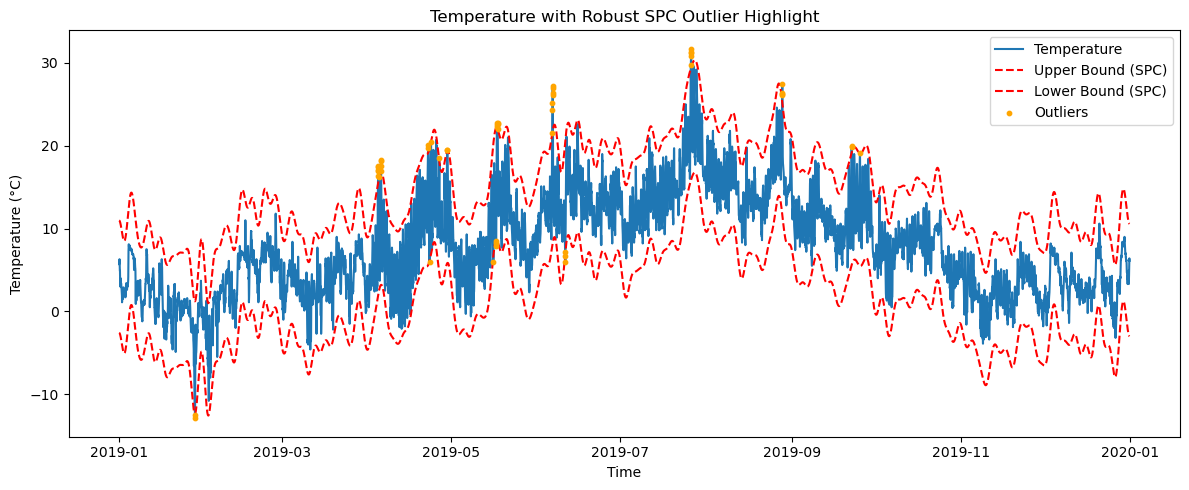

In [26]:
import numpy as np
from scipy.fft import dct, idct
import matplotlib.pyplot as plt

def plot_temperature_with_outliers_matplotlib(
    df,
    dct_cutoff=200,
    n_std=3.5,
    temp_col="temperature_2m",
    time_col="time",
    ax=None,
    return_summary=True,
    robust=True,
    scale_mad=True,
    ):
    """
    Plot temperature as a function of time, highlight outliers using robust SPC boundaries
    based on seasonally adjusted temperature variations (SATV) from high-pass DCT filtering.

    Parameters:
        df: DataFrame with temperature and time columns
        dct_cutoff: int, frequency cutoff for DCT (default 200)
        n_std: float, number of robust std deviations for outlier boundary (default 3.5)
        temp_col: str, column name for temperature
        time_col: str, column name for time
        ax: matplotlib axis (optional)
        return_summary: bool, whether to return outlier summary
        robust: bool, use median/MAD if True, else mean/std
        scale_mad: bool, scale MAD by 1.4826 to estimate std
    Returns:
        fig, ax, summary_dict (if return_summary)
    """
    # Validate parameters
    if not isinstance(dct_cutoff, int) or dct_cutoff <= 0 or dct_cutoff > len(df):
        raise ValueError(f"dct_cutoff must be an integer between 1 and the length of the dataset ({len(df)}). Got {dct_cutoff}.")
    if not isinstance(n_std, (int, float)) or n_std <= 0:
        raise ValueError(f"n_std must be a positive number. Got {n_std}.")

    # Extract temperature and time
    temp_data = df[temp_col].values.astype(float)
    time_data = df[time_col]

    # Interpolate missing values for DCT
    if np.isnan(temp_data).any():
        nans = np.isnan(temp_data)
        not_nans = ~nans
        temp_data[nans] = np.interp(np.where(nans)[0], np.where(not_nans)[0], temp_data[not_nans])

    # DCT low-pass for trend
    X = dct(temp_data, norm="ortho")
    X_lp = np.zeros_like(X)
    X_lp[:dct_cutoff] = X[:dct_cutoff]
    trend = idct(X_lp, norm="ortho")

    # SATV (high-pass)
    satv = temp_data - trend

    # Robust or classical limits in SATV space
    if robust:
        center = np.median(satv)
        mad = np.median(np.abs(satv - center))
        spread = (1.4826 * mad) if scale_mad else mad
    else:
        center = np.mean(satv)
        spread = np.std(satv)

    upper_satv = center + n_std * spread
    lower_satv = center - n_std * spread

    # Map limits to temperature space
    upper_curve = trend + upper_satv
    lower_curve = trend + lower_satv

    # Outliers in SATV space
    outliers = (satv < lower_satv) | (satv > upper_satv)
    outlier_indices = np.where(outliers)[0]

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure
    ax.plot(time_data, temp_data, label="Temperature", color="#1f77b4")
    ax.plot(time_data, upper_curve, color="red", linestyle="--", label="Upper Bound (SPC)")
    ax.plot(time_data, lower_curve, color="red", linestyle="--", label="Lower Bound (SPC)")
    ax.scatter(
        time_data.iloc[outlier_indices],
        temp_data[outlier_indices],
        color="orange",
        label="Outliers",
        s=10,
        zorder=3,
    )
    ax.set_title("Temperature with Robust SPC Outlier Highlight")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    summary = None
    if return_summary:
        summary = {
            "n_outliers": int(np.sum(outliers)),
            "n_total": len(temp_data),
            "outlier_fraction": float(np.sum(outliers)) / len(temp_data),
            "outlier_times": time_data.iloc[outlier_indices].tolist(),
            "outlier_values": temp_data[outlier_indices].tolist(),
            "spc_lower": lower_curve.min(),
            "spc_upper": upper_curve.max(),
            "dct_cutoff": dct_cutoff,
            "n_std": n_std,
            "robust": robust,
            "scale_mad": scale_mad,
        }
        return fig, ax, summary
    return fig, ax

# Plotting
fig, ax, summary = plot_temperature_with_outliers_matplotlib(df_bergen)

/Users/henrikengdal/Documents/GitHub/IND320-henrikengdal-project/.conda/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:322: UserWarning:

Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.



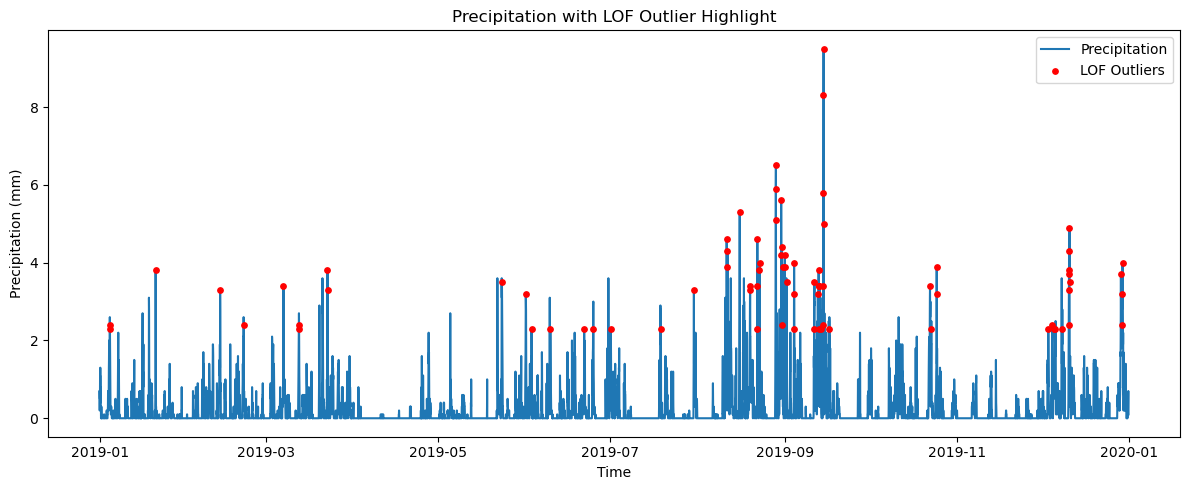

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

def plot_precipitation_with_lof_outliers_matplotlib(
    df,
    n_neighbors=20,
    contamination=0.01,
    precip_col="precipitation",
    time_col="time",
    ax=None,
    return_summary=True,
):
    """
    Plot precipitation as a function of time, highlight outliers using Local Outlier Factor (LOF).
    Parameters:
        df: DataFrame with precipitation and time columns
        n_neighbors: int, number of neighbors for LOF
        contamination: float, expected proportion of outliers
        precip_col: str, column name for precipitation
        time_col: str, column name for time
        ax: matplotlib axis (optional)
        return_summary: bool, whether to return outlier summary
    Returns:
        fig, ax, summary_dict (if return_summary)
    """
    # Extract precipitation and time
    precip_data = df[precip_col].values.reshape(-1, 1)
    time_data = df[time_col]

    # Remove NaNs for LOF
    mask = ~np.isnan(precip_data.flatten())
    precip_data_clean = precip_data[mask]
    time_data_clean = time_data.iloc[mask]

    # Fit LOF
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    lof_labels = lof.fit_predict(precip_data_clean)
    outliers = lof_labels == -1
    outlier_indices = np.where(outliers)[0]

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure
    ax.plot(time_data_clean, precip_data_clean, label="Precipitation", color="#1f77b4")
    ax.scatter(
        time_data_clean.iloc[outlier_indices],
        precip_data_clean[outlier_indices],
        color="red",
        label="LOF Outliers",
        s=15,
        zorder=3,
    )
    ax.set_title("Precipitation with LOF Outlier Highlight")
    ax.set_xlabel("Time")
    ax.set_ylabel("Precipitation (mm)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    summary = None
    if return_summary:
        summary = {
            "n_outliers": int(np.sum(outliers)),
            "n_total": len(precip_data_clean),
            "outlier_fraction": float(np.sum(outliers)) / len(precip_data_clean),
            "outlier_times": time_data_clean.iloc[outlier_indices].tolist(),
            "outlier_values": precip_data_clean[outlier_indices].flatten().tolist(),
            "n_neighbors": n_neighbors,
            "contamination": contamination,
        }
        return fig, ax, summary
    return fig, ax

# Example usage for Bergen precipitation data
fig, ax, summary = plot_precipitation_with_lof_outliers_matplotlib(df_bergen)


## Seasonal-Trend decomposition using LOESS (STL)


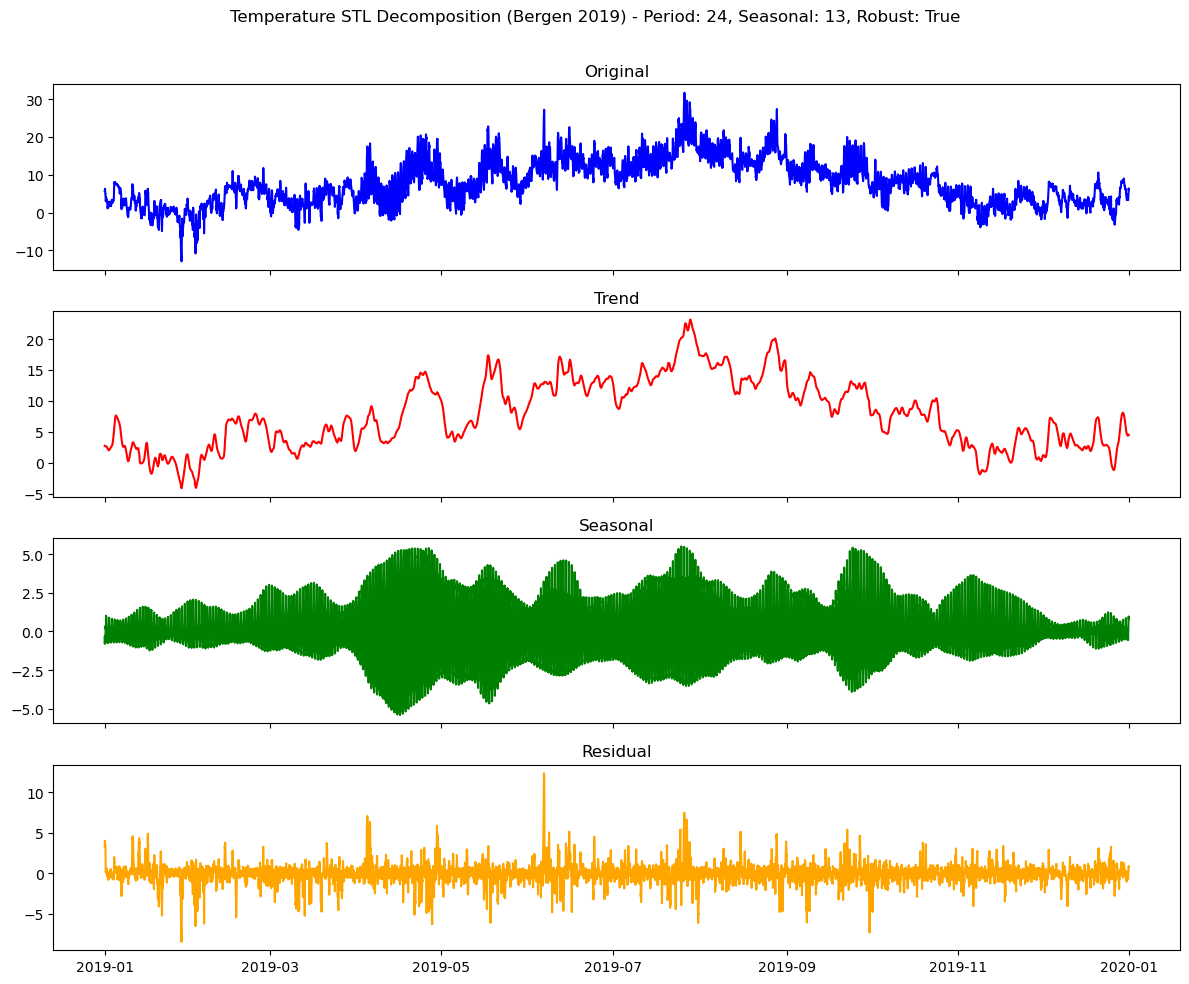

STL Decomposition Results:
Seasonal strength: 0.670
Trend strength: 0.951


In [11]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pandas as pd

def plot_stl_decomposition_matplotlib(df, value_col='production_mwh', time_col='time', 
                          period=24*7, seasonal=7, trend=None, robust=True,
                          title_prefix="STL Decomposition"):
    """
    Perform STL decomposition on time series data and create a Matplotlib plot.
    """
    # Set time as index if not already
    if time_col in df.columns:
        ts_data = df.set_index(time_col)[value_col]
    else:
        ts_data = df[value_col]
    ts_data = ts_data.dropna()
    period_int = int(round(period))
    if period_int < 2:
        raise ValueError(f"period must be >= 2, got {period}")
    def _ensure_odd(n):
        if n is None:
            return None
        n_int = int(round(n))
        return n_int if n_int % 2 == 1 else n_int + 1
    seasonal_odd = _ensure_odd(seasonal)
    trend_odd = _ensure_odd(trend)
    stl = STL(ts_data, period=period_int, seasonal=seasonal_odd, trend=trend_odd, robust=robust)
    stl_result = stl.fit()
    # Plot with matplotlib
    fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    axs[0].plot(stl_result.observed.index, stl_result.observed.values, color='blue')
    axs[0].set_title('Original')
    axs[1].plot(stl_result.trend.index, stl_result.trend.values, color='red')
    axs[1].set_title('Trend')
    axs[2].plot(stl_result.seasonal.index, stl_result.seasonal.values, color='green')
    axs[2].set_title('Seasonal')
    axs[3].plot(stl_result.resid.index, stl_result.resid.values, color='orange')
    axs[3].set_title('Residual')
    plt.suptitle(f"{title_prefix} - Period: {period_int}, Seasonal: {seasonal_odd}, Robust: {robust}")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return stl_result

# Test the function with Bergen temperature data (use daily seasonality)
stl_temp_result = plot_stl_decomposition_matplotlib(
    df_bergen, 
    value_col='temperature_2m',
    time_col='time',
    period=24,        # Daily cycle for hourly data
    seasonal=13,      # Seasonal smoother length (odd)
    title_prefix="Temperature STL Decomposition (Bergen 2019)"
    )

# Display decomposition statistics
print("STL Decomposition Results:")
print(f"Seasonal strength: {1 - stl_temp_result.resid.var() / (stl_temp_result.seasonal + stl_temp_result.resid).var():.3f}")
print(f"Trend strength: {1 - stl_temp_result.resid.var() / (stl_temp_result.trend + stl_temp_result.resid).var():.3f}")

## Spectrogram

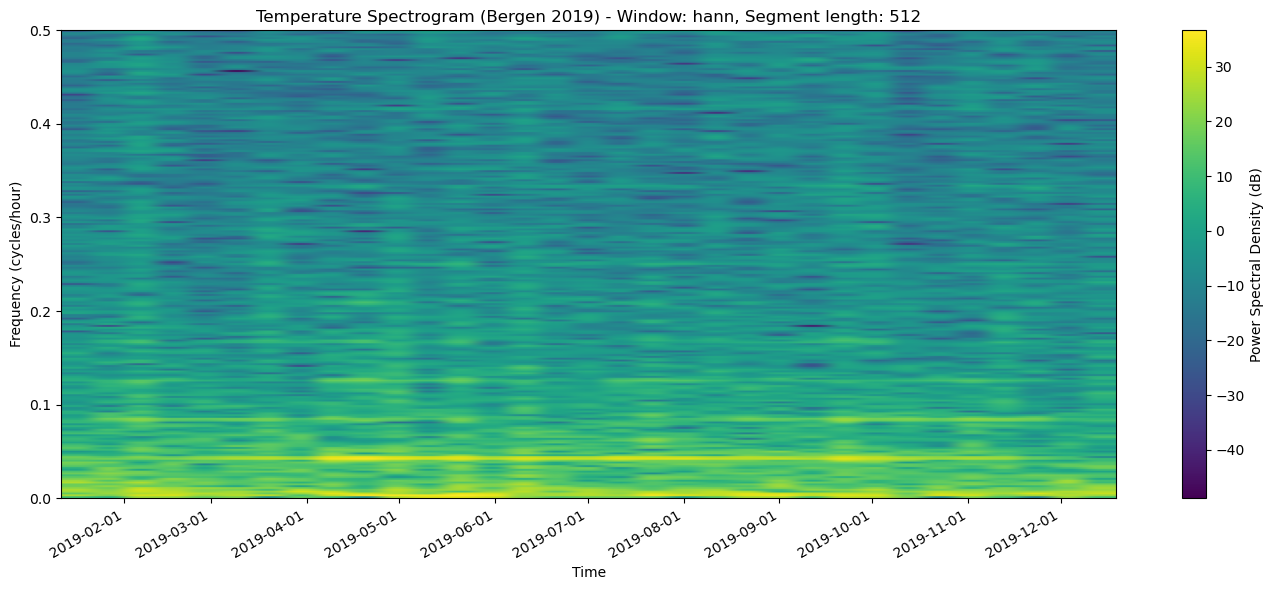

Spectrogram Analysis Results:
Sampling frequency: 1.00 samples/hour
Frequency resolution: 0.0020 cycles/hour
Time resolution: 256.00 hours
Number of frequency bins: 257
Number of time segments: 33
Power range: -48.8 to 36.6 dB


In [13]:
import numpy as np
from scipy import signal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def create_spectrogram_matplotlib(df, value_col='production_mwh', time_col='time', 
                              window='hann', nperseg=256, noverlap=None, 
                              title_prefix="Spectrogram"):
    """
    Create a spectrogram visualization for time series data using Matplotlib.
    
    Parameters:
    - df: DataFrame with time series data
    - value_col: Column name containing the values to analyze
    - time_col: Column name containing datetime values
    - window: Window function ('hann', 'hamming', 'blackman', etc.)
    - nperseg: Length of each segment (window size)
    - noverlap: Number of points to overlap between segments (default: nperseg//8)
    - title_prefix: Prefix for plot title
    
    Returns:
    - spec_data: Dictionary with spectrogram data (frequencies, times, Sxx)
    """
    # Set default overlap if not provided
    if noverlap is None:
        noverlap = nperseg // 8
    
    # Extract time series data
    if time_col in df.columns:
        ts_data = df.set_index(time_col)[value_col]
    else:
        ts_data = df[value_col]
    
    # Remove NaN values
    ts_data = ts_data.dropna()
    
    # Calculate sampling frequency (assuming regular intervals)
    time_diff = ts_data.index.to_series().diff().median()
    fs = 1 / (time_diff.total_seconds() / 3600)  # Convert to samples per hour
    
    # Compute spectrogram
    frequencies, times, Sxx = signal.spectrogram(
        ts_data.values, 
        fs=fs, 
        window=window, 
        nperseg=nperseg, 
        noverlap=noverlap,
        scaling='density'
    )
    
    # Convert power spectral density to dB
    Sxx_db = 10 * np.log10(Sxx + 1e-10)  # Add small value to avoid log(0)
    
    # Convert time segments back to datetime
    start_time = ts_data.index[0]
    time_segments = [start_time + pd.Timedelta(hours=t) for t in times]
    
    # Create spectrogram plot with matplotlib
    fig, ax = plt.subplots(figsize=(14, 6))
    extent = [mdates.date2num(time_segments[0]), mdates.date2num(time_segments[-1]), frequencies[0], frequencies[-1]]
    im = ax.imshow(Sxx_db, aspect='auto', origin='lower', extent=extent, cmap='viridis')
    cbar = fig.colorbar(im, ax=ax, label="Power Spectral Density (dB)")
    ax.set_title(f"{title_prefix} - Window: {window}, Segment length: {nperseg}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency (cycles/hour)")
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    
    # Prepare return data
    spec_data = {
        'frequencies': frequencies,
        'times': times,
        'time_segments': time_segments,
        'Sxx': Sxx,
        'Sxx_db': Sxx_db,
        'sampling_freq': fs,
        'window': window,
        'nperseg': nperseg,
        'noverlap': noverlap
    }
    
    return spec_data

# Test the function with Bergen temperature data
spec_data = create_spectrogram_matplotlib(
    df_bergen,
    value_col='temperature_2m',
    time_col='time',
    window='hann',
    nperseg=512,  # Larger window for better frequency resolution
    noverlap=256,  # 50% overlap
    title_prefix="Temperature Spectrogram (Bergen 2019)"
)

# Display spectrogram statistics
print("Spectrogram Analysis Results:")
print(f"Sampling frequency: {spec_data['sampling_freq']:.2f} samples/hour")
print(f"Frequency resolution: {spec_data['frequencies'][1] - spec_data['frequencies'][0]:.4f} cycles/hour")
print(f"Time resolution: {spec_data['times'][1] - spec_data['times'][0]:.2f} hours")
print(f"Number of frequency bins: {len(spec_data['frequencies'])}")
print(f"Number of time segments: {len(spec_data['times'])}")
print(f"Power range: {spec_data['Sxx_db'].min():.1f} to {spec_data['Sxx_db'].max():.1f} dB")

## Word log

For this part, I found myself using AI more frequently to understand what was being asked for in the CA description than I did with the previous two parts. I think this was mainly because the expectations were phrased in a way that required some interpretation, and AI tools like ChatGPT helped me clarify the intent before I started implementing anything. Either way, I think we’ve arrived at something that covers all the necessary points and demonstrates a clear understanding of the task requirements.

Starting with the Streamlit experience, this section was relatively straightforward, but it did include a few challenges that required trial and error. The most difficult part was understanding how to reorder and manage the pages correctly while maintaining consistent naming and navigation. Once I figured that out, the implementation process went much more smoothly. The “new A” page was implemented without major issues. I used GitHub Copilot to get a sense of what the “necessary UI elements” might look like, and it provided good suggestions that aligned closely with what I needed. There were still a few moments where I had to manually adjust the layout or functionality, but overall the experience was productive.

The “new B” page, however, brought a few challenges, especially with implementing caching for selections made in the “Energy Production Analysis” page. It took some testing and revisions to get everything working as intended, but I’m satisfied with the final behavior.

The notebook part of the assignment was also quite manageable. Since this section required creating and refining several methods, I used AI support mainly for generating documentation and improving code readability. This not only saved time but also helped maintain consistency across the different components of the project.

Overall, I gained a better understanding of how to structure the Streamlit application effectively.



